# Problem C: Surrogate Modeling for Steady-State Heat Conduction in Heterogeneous Materials

Consider the steady-state heat conduction problem in a heterogeneous solid material occupying the unit square domain $\Omega = [0,1]^2$:

$$
\begin{split}
-\nabla\cdot(a(x,y)\nabla u) &= f,\quad (x,y)\in\Omega=[0,1]^2 \\
u &= 0,\quad (x,y)\in\partial\Omega
\end{split} \tag{2}
$$

where $u(x,y)$ denotes the temperature field, $a(x,y) > 0$ denotes the spatially varying thermal conductivity of the material, and the uniform heat source is given by $f = 10$. The zero Dirichlet boundary condition models a configuration in which the boundary of the domain is kept at a fixed reference temperature.

In computational materials science, evaluating the thermal response of a large number of candidate microstructures is a central bottleneck in material screening and design workflows. Although high-fidelity Finite Element Method (FEM) solvers can produce accurate solutions, they are computationally expensive when applied repeatedly to thousands of different conductivity fields $a(x,y)$.

## Task: Learning the Solution Operator $a(x,y) \mapsto u(x,y)$

The goal of this task is to make a fast prediction of the temperature field $u(x,y)$ given $a(x,y)$. To this end, a dataset of input-output pairs $\{a^{(j)}, u^{(j)}\}$ has been pre-computed using a high-precision FEM solver. The conductivity fields $a^{(j)}$ are sampled from a distribution $\mathcal{A}$ over spatially heterogeneous functions, representative of realistic microstructural variability in composite materials. Once trained, the model should accurately predict the temperature field for new, unseen conductivity samples drawn from the same distribution $\mathcal{A}$, at a fraction of the cost of a full FEM solve.

### Goals

- Please select a suitable deep learning method for this task and justify your choice.
- Report your implementation setup, including network architecture, activation function, optimizer (with learning rate), number of epochs, batch size, loss formulation, and any additional techniques used for improvement.
- Compute the $L^2$ relative error on the **test dataset** at each training epoch and plot the `Error vs. Epoch` curve (reporting the final error). The $L^2$ relative error between predictions $\{u^{(j)}_{\text{pred}}\}_{j=1}^{N}$ and ground truth $\{u^{(j)}_{\text{true}}\}_{j=1}^{N}$ is defined as:

$$
\text{error} = \frac{1}{N}\sum_{j=1}^{N}\sqrt{\frac{\sum_i\left|u^{(j)}_{\text{pred}}(x_i)-u^{(j)}_{\text{true}}(x_i)\right|^2}{\sum_i\left|u^{(j)}_{\text{true}}(x_i)\right|^2}}
$$

where $j$ indexes the sample and $i$ indexes the spatial grid point.

- For the **first test instance**, use `matplotlib` to plot the following in separate figures:
  1. The input conductivity field $a(x,y)$
  2. The predicted temperature field $u_{\text{pred}}(x,y)$
  3. The ground truth temperature field $u_{\text{true}}(x,y)$
  4. The pointwise absolute error $|u_{\text{pred}} - u_{\text{true}}|$

### Dataset

The training and test data are provided in `ProblemC_dataset.h5`:

| Key | Shape | Description |
|---|---|---|
| `a_train` | (1000, 128, 128) | Training conductivity fields sampled from $\mathcal{A}$ |
| `u_train` | (1000, 128, 128) | Corresponding FEM-computed temperature fields (training) |
| `a_test` | (200, 128, 128) | Test conductivity fields (for error evaluation only, **do not use for training**) |
| `u_test` | (200, 128, 128) | Corresponding FEM-computed temperature fields (test reference, **do not use for training**) |
| `X` | (128, 128) | $x$-coordinates of the $128\times 128$ regular spatial grid |
| `Y` | (128, 128) | $y$-coordinates of the $128\times 128$ regular spatial grid |

> 📥 Dataset download: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

<KeysViewHDF5 ['X', 'Y', 'a_test', 'a_train', 'u_test', 'u_train']>
The shape of X: torch.Size([128, 128]) The shape of Y: torch.Size([128, 128])
The shape of a_train: torch.Size([1000, 128, 128])
The shape of u_train: torch.Size([1000, 128, 128])
The shape of a_test: torch.Size([200, 128, 128])
The shape of u_test: torch.Size([200, 128, 128])


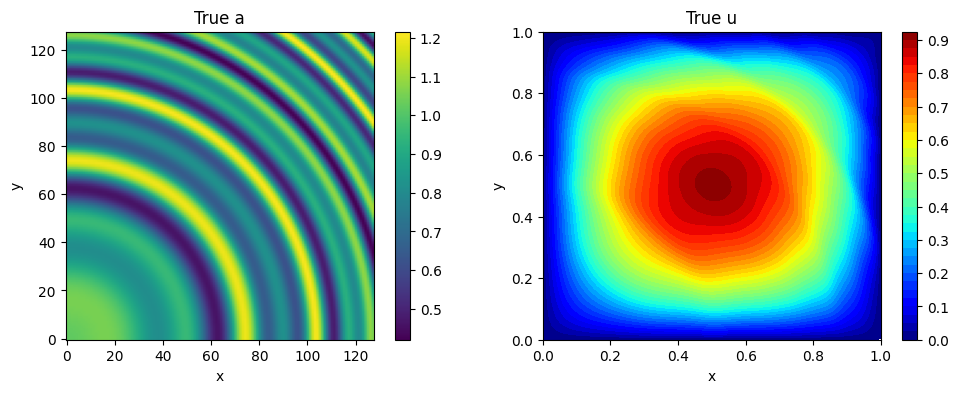

In [2]:
import numpy as np
import h5py
import torch 
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
device = 'cpu'
dtype = torch.float32
######################################
# Load training data
######################################
with h5py.File('ProblemC_dataset.h5', 'r') as data:
    print(data.keys())
    a_train = torch.tensor(np.array(data["a_train"]), dtype=dtype)
    u_train = torch.tensor(np.array(data["u_train"]), dtype=dtype)
    a_test = torch.tensor(np.array(data["a_test"]), dtype=dtype)
    u_test =torch.tensor( np.array(data["u_test"]), dtype=dtype)
    # The coordinates
    X = torch.tensor(np.array(data['X']), dtype=dtype)
    Y = torch.tensor(np.array(data['Y']), dtype=dtype)
print('The shape of X:', X.shape, 'The shape of Y:', Y.shape)
print('The shape of a_train:', a_train.shape)
print('The shape of u_train:', u_train.shape)
print('The shape of a_test:', a_test.shape)
print('The shape of u_test:', u_test.shape)

####### Visualize the training data 
a_show, u_show = a_train[1], u_train[1]
#
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
#
cntr0 = axs.flat[:][0].imshow(a_show, origin='lower')
fig.colorbar(cntr0, ax=axs.flat[:][0])
axs.flat[:][0].set_title('True a')
axs.flat[:][0].set_xlabel('x')
axs.flat[:][0].set_ylabel('y')
#
cntr1 = axs.flat[:][1].contourf(X, Y, u_show, levels=40, cmap='jet')
fig.colorbar(cntr1, ax=axs.flat[:][1])
axs.flat[:][1].set_title('True u')
axs.flat[:][1].set_xlabel('x')
axs.flat[:][1].set_ylabel('y')
#
plt.show()

Using device: cuda

Keys: <KeysViewHDF5 ['X', 'Y', 'a_test', 'a_train', 'u_test', 'u_train']>

The shape of X: torch.Size([128, 128])
The shape of Y: torch.Size([128, 128])
The shape of a_train: torch.Size([1000, 128, 128])
The shape of u_train: torch.Size([1000, 128, 128])
The shape of a_test: torch.Size([200, 128, 128])
The shape of u_test: torch.Size([200, 128, 128])

The shape of ax_train: torch.Size([1000, 128, 128, 3])
The shape of u_train: torch.Size([1000, 128, 128, 1])
The shape of ax_test: torch.Size([200, 128, 128, 3])
The shape of u_test: torch.Size([200, 128, 128, 1])


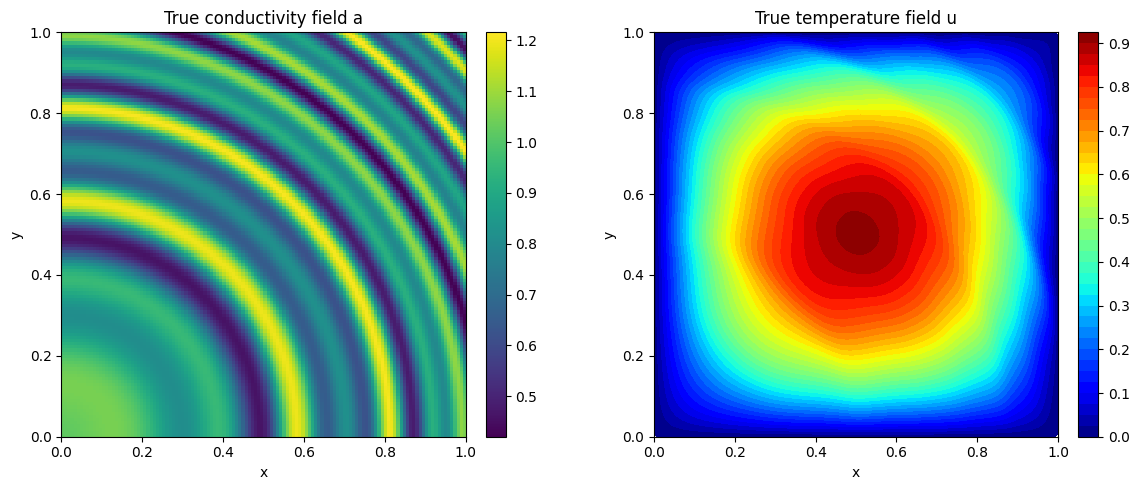

3,552,593 trainable parameters.


  5%|▌         | 50/1000 [02:33<48:16,  3.05s/it] 

Epoch:50, loss:3.199424e-02, test_error:6.932675e-03, best_error:6.046919e-03, lr:1.000e-03


 10%|█         | 100/1000 [05:05<45:42,  3.05s/it]

Epoch:100, loss:1.591352e-02, test_error:7.942031e-03, best_error:5.145351e-03, lr:1.000e-03


...

 95%|█████████▌| 950/1000 [47:46<02:30,  3.02s/it]

Epoch:950, loss:5.907518e-03, test_error:4.938978e-03, best_error:4.396078e-03, lr:1.250e-04


100%|██████████| 1000/1000 [50:15<00:00,  3.02s/it]

Epoch:1000, loss:5.791196e-03, test_error:4.649933e-03, best_error:4.396078e-03, lr:6.250e-05
Training time: 3015.735522508621
Best test L2 relative error: 0.004396077767014503


The shape of u_test_pred: torch.Size([200, 128, 128, 1])
Final average L2 relative error: 0.004396077711135149


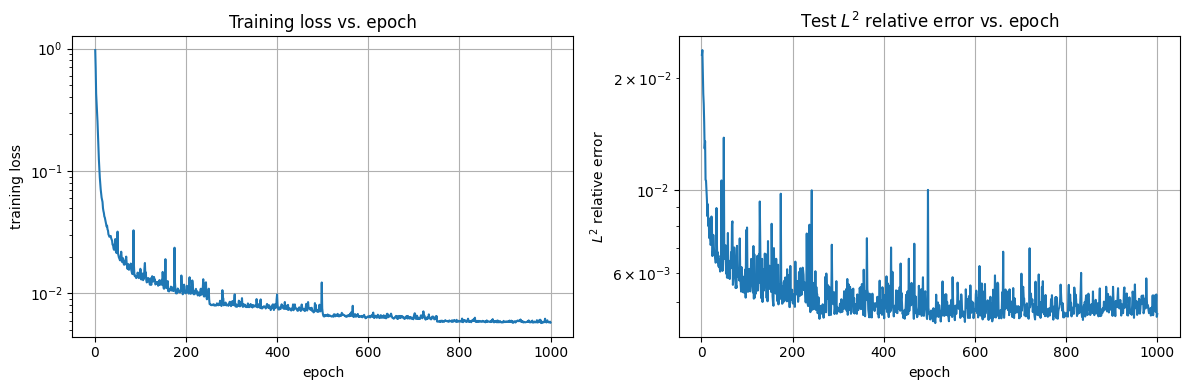

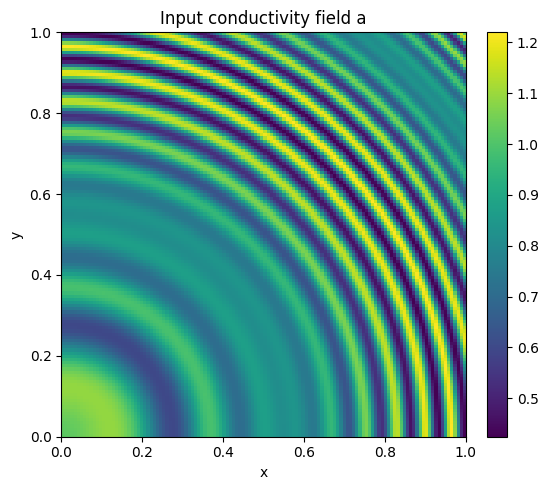

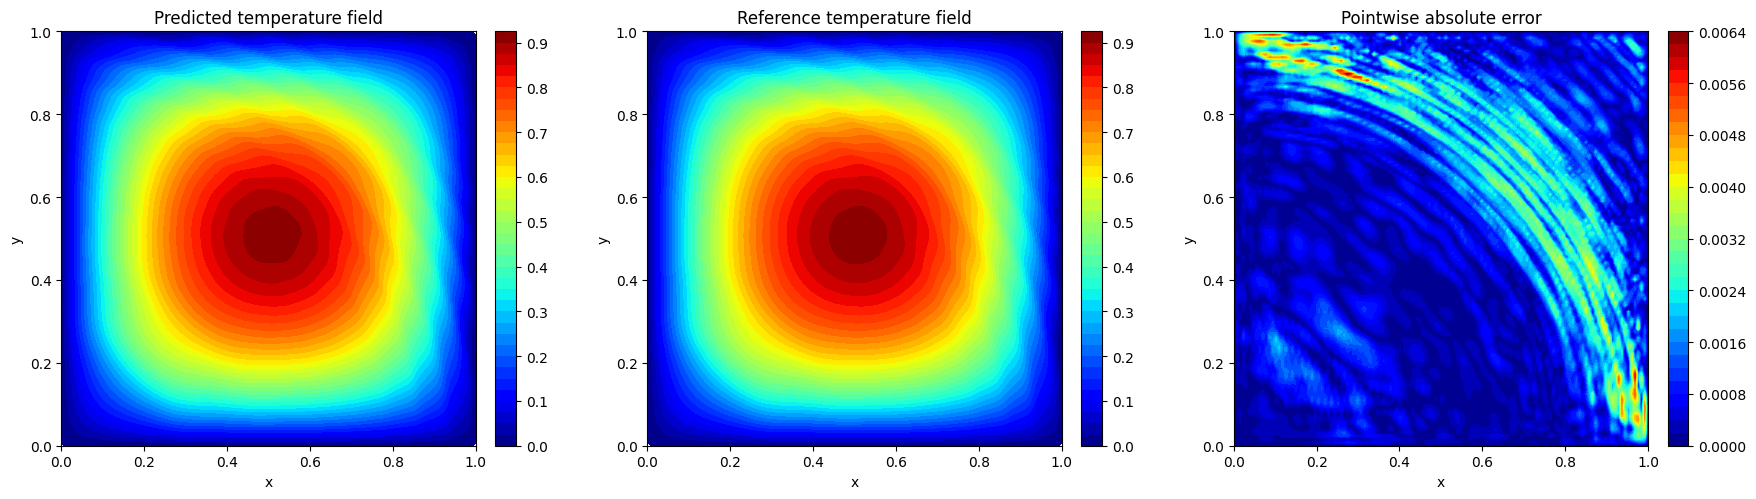

In [1]:
#############################################################
# Problem C: Learning the solution operator a(x,y) -> u(x,y)
# Method: Fourier Neural Operator (FNO)
#############################################################


#############################################################
# Step 0: Import packages and global settings
#############################################################

import os
import time
import h5py
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from tqdm import trange
from torch.utils.data import Dataset, DataLoader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

np.random.seed(1234)
torch.manual_seed(1234)

if device.type == "cuda":
    torch.cuda.manual_seed_all(1234)
    torch.backends.cudnn.benchmark = True

print("Using device:", device)


#############################################################
# Step 1: Load dataset
#############################################################

with h5py.File("ProblemC_dataset.h5", "r") as data:
    print("\nKeys:", data.keys())

    a_train = torch.tensor(np.array(data["a_train"]), dtype=dtype)
    u_train = torch.tensor(np.array(data["u_train"]), dtype=dtype)
    a_test = torch.tensor(np.array(data["a_test"]), dtype=dtype)
    u_test = torch.tensor(np.array(data["u_test"]), dtype=dtype)
    X = torch.tensor(np.array(data["X"]), dtype=dtype)
    Y = torch.tensor(np.array(data["Y"]), dtype=dtype)

print("\nThe shape of X:", X.shape)
print("The shape of Y:", Y.shape)
print("The shape of a_train:", a_train.shape)
print("The shape of u_train:", u_train.shape)
print("The shape of a_test:", a_test.shape)
print("The shape of u_test:", u_test.shape)


#############################################################
# Step 2: Prepare FNO input ax = [a(x,y), x, y]
#############################################################

def prepare_ax(a, X, Y):
    """
    Input:
        a: torch tensor, shape (N, 128, 128)
        X: torch tensor, shape (128, 128)
        Y: torch tensor, shape (128, 128)
    Return:
        ax: torch tensor, shape (N, 128, 128, 3)
    Function:
        Build FNO input:
            ax[...,0] = a(x,y)
            ax[...,1] = x
            ax[...,2] = y
    """

    ndata = a.shape[0]
    nx = a.shape[1]
    ny = a.shape[2]

    a = a.reshape(ndata, nx, ny, 1)

    grid = torch.stack([X, Y], dim=-1)
    grid = grid.reshape(1, nx, ny, 2)
    grid = grid.repeat(ndata, 1, 1, 1)

    ax = torch.cat([a, grid], dim=-1)

    return ax


ax_train = prepare_ax(a_train, X, Y)
ax_test = prepare_ax(a_test, X, Y)

u_train = u_train.reshape(u_train.shape[0], u_train.shape[1], u_train.shape[2], 1)
u_test = u_test.reshape(u_test.shape[0], u_test.shape[1], u_test.shape[2], 1)

print("\nThe shape of ax_train:", ax_train.shape)
print("The shape of u_train:", u_train.shape)
print("The shape of ax_test:", ax_test.shape)
print("The shape of u_test:", u_test.shape)


#############################################################
# Step 3: Visualize one training sample
#############################################################

sample_id = 1

a_show = a_train[sample_id]
u_show = u_train[sample_id, ..., 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Conductivity field a
cntr0 = axes[0].imshow(a_show, origin="lower", extent=[0, 1, 0, 1], cmap="viridis", aspect="equal")
fig.colorbar(cntr0, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].set_title("True conductivity field a")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Temperature field u
cntr1 = axes[1].contourf(X, Y, u_show, levels=40, cmap="jet")
fig.colorbar(cntr1, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_title("True temperature field u")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()


#############################################################
# Step 4: Define Spectral Convolution Layer
#############################################################

class SpectralConv2d(nn.Module):

    def __init__(self, in_size, out_size, modes1, modes2, dtype=None):
        super(SpectralConv2d, self).__init__()
        """
        2D Fourier layer:
            FFT -> truncate low Fourier modes -> linear transform -> inverse FFT
        Input:
            x: shape (batch_size, in_size, nx, ny)
        Return:
            x: shape (batch_size, out_size, nx, ny)
        """

        self.in_size = in_size
        self.out_size = out_size
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = 1.0 / (in_size * out_size)

        if dtype is None or dtype == torch.float32:
            ctype = torch.complex64
        elif dtype == torch.float64:
            ctype = torch.complex128
        else:
            raise TypeError("Unsupported dtype.")

        self.weight1 = nn.Parameter(self.scale * torch.randn(in_size, out_size, modes1, modes2, dtype=ctype))
        self.weight2 = nn.Parameter(self.scale * torch.randn(in_size, out_size, modes1, modes2, dtype=ctype))

    def compl_mul_2d(self, input, weights):
        """
        Complex multiplication.
        Input:
            input:   shape (batch_size, in_size, modes1, modes2)
            weights: shape (in_size, out_size, modes1, modes2)
        Return:
            output: shape (batch_size, out_size, modes1, modes2)
        """

        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        """
        Input:
            x: shape (batch_size, in_size, nx, ny)
        Return:
            x: shape (batch_size, out_size, nx, ny)
        """

        batch_size = x.shape[0]

        # Fourier transform
        x_ft = torch.fft.rfft2(x)

        # Allocate Fourier coefficients
        out_ft = torch.zeros(batch_size, self.out_size, x.size(-2), x.size(-1) // 2 + 1, device=x.device, dtype=torch.cfloat)

        # Positive low-frequency modes
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul_2d(x_ft[:, :, :self.modes1, :self.modes2], self.weight1)

        # Negative low-frequency modes in first direction
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul_2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weight2)

        # Inverse Fourier transform
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

        return x


#############################################################
# Step 5: Define FNO2d model
#############################################################

class FNO2d(nn.Module):

    def __init__(self, in_size: int, out_size: int, modes1: int, modes2: int, hidden_list: list, dtype=None, hard_bc=True):
        super(FNO2d, self).__init__()
        """
        FNO2d for learning:
            a(x,y) -> u(x,y)
        Input:
            ax: shape (batch_size, 128, 128, 3)
        Output:
            u: shape (batch_size, 128, 128, 1)
        """

        self.hidden_list = hidden_list
        self.hard_bc = hard_bc

        self.activation = nn.GELU()

        # Input lifting layer
        self.fc_in = nn.Linear(in_size, hidden_list[0], dtype=dtype)

        # Fourier layers and pointwise linear layers
        conv_net = []
        w_net = []

        self.hidden_in = hidden_list[0]

        for hidden in hidden_list[1:]:
            conv_net.append(SpectralConv2d(self.hidden_in, hidden, modes1, modes2, dtype=dtype))
            w_net.append(nn.Conv1d(self.hidden_in, hidden, kernel_size=1, dtype=dtype))
            self.hidden_in = hidden

        self.spectral_conv = nn.Sequential(*conv_net)
        self.weight_conv = nn.Sequential(*w_net)

        # Output projection layer
        self.fc_out0 = nn.Linear(self.hidden_in, 128, dtype=dtype)
        self.fc_out1 = nn.Linear(128, out_size, dtype=dtype)

    def forward(self, ax):
        """
        Input:
            ax: shape (batch_size, nx, ny, 3)
        Return:
            u: shape (batch_size, nx, ny, 1)
        """

        batch_size = ax.shape[0]
        nx = ax.shape[1]
        ny = ax.shape[2]

        # Save grid for hard boundary condition
        x_grid = ax[..., 1:2]
        y_grid = ax[..., 2:3]

        # Input lifting:
        # (batch, nx, ny, in_size) -> (batch, nx, ny, hidden)
        ax = self.fc_in(ax)

        # Move channel to second dimension:
        # (batch, nx, ny, hidden) -> (batch, hidden, nx, ny)
        ax = ax.permute(0, 3, 1, 2)

        hidden_last = self.hidden_list[0]

        # Fourier layers
        for conv, weight, hidden_size in zip(self.spectral_conv, self.weight_conv, self.hidden_list[1:]):
            ax1 = conv(ax)
            ax2 = weight(ax.reshape(batch_size, hidden_last, -1)).reshape(batch_size, hidden_size, nx, ny)
            ax = self.activation(ax1 + ax2)
            hidden_last = hidden_size

        # Move channel back:
        # (batch, hidden, nx, ny) -> (batch, nx, ny, hidden)
        ax = ax.permute(0, 2, 3, 1)

        ax = self.fc_out0(ax)
        ax = self.activation(ax)

        u = self.fc_out1(ax)

        # Hard homogeneous Dirichlet boundary (Mollifier):
        # u = x(1-x)y(1-y) * raw
        if self.hard_bc:
            u = x_grid * (1.0 - x_grid) * y_grid * (1.0 - y_grid) * u

        return u


#############################################################
# Step 6: Define normalizer
#############################################################

class UnitGaussianNormalizer(object):

    def __init__(self, ax, eps=1e-8):
        """
        Apply normalization to the first channel of the last axis.
        Input:
            ax: torch tensor, shape (N, nx, ny, c)
        For ax = [a, x, y]:
            normalize only a, keep x,y unchanged.
        For u:
            normalize u.
        """

        self.mean = torch.mean(ax[..., 0:1], dim=0)
        self.std = torch.std(ax[..., 0:1], dim=0)
        self.eps = eps

    def encode(self, ax):
        """
        Input:
            ax: torch tensor, shape (N, nx, ny, c)
        Return:
            ax_norm: same shape as ax
        """
        d = ax.shape[-1] - 1
        ax_list = torch.split(ax, split_size_or_sections=[1, d], dim=-1)
        ax = torch.cat([(ax_list[0] - self.mean) / (self.std + self.eps), ax_list[1]], dim=-1)

        return ax

    def decode(self, ax):
        """
        Input:
            ax_norm: torch tensor, shape (N, nx, ny, c)
        Return:
            ax: same shape as ax_norm
        """
        d = ax.shape[-1] - 1
        ax_list = torch.split(ax, split_size_or_sections=[1, d], dim=-1)
        ax = torch.cat([ax_list[0] * (self.std + self.eps) + self.mean, ax_list[1]], dim=-1)

        return ax
    
#############################################################
# Step 7: Create model and normalizers
#############################################################

# Move training data to GPU for computing normalizer statistics
ax_train_gpu = ax_train.to(device)
u_train_gpu = u_train.to(device)

normalizer_ax = UnitGaussianNormalizer(ax_train_gpu)
normalizer_u = UnitGaussianNormalizer(u_train_gpu)

# Model hyperparameters
modes1 = 16
modes2 = 16
hidden_list = [48, 48, 48, 48]

model_u = FNO2d(in_size=ax_train.shape[-1], out_size=u_train.shape[-1], modes1=modes1, modes2=modes2, hidden_list=hidden_list, dtype=dtype, hard_bc=True).to(device)

total_trainable_params = sum(p.numel() for p in model_u.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} trainable parameters.")


#############################################################
# Step 8: Define dataset and dataloader
#############################################################

class MyDataset(Dataset):

    def __init__(self, ax, u):
        """
        Input:
            ax: shape (N, 128, 128, 3)
            u:  shape (N, 128, 128, 1)
        """
        self.ax = ax
        self.u = u

    def __getitem__(self, index):
        return self.ax[index], self.u[index]

    def __len__(self):
        return self.ax.shape[0]


batch_size = 32

train_loader = DataLoader(MyDataset(ax_train, u_train), batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True if device.type == "cuda" else False)      ###


#############################################################
# Step 9: Define loss class
#############################################################

class LossClass(object):

    def __init__(self, u_model):
        self.device = device
        self.u_model = u_model

    def loss_data(self, ax_batch, u_batch):
        """
        Supervised data loss for operator learning.
        Input:
            ax_batch: shape (batch_size, 128, 128, 3)
            u_batch:  shape (batch_size, 128, 128, 1)
        Return:
            loss: MSE loss in normalized u-space
        """

        ax = ax_batch.to(self.device, non_blocking=True)            ### 把 ax_batch 和 u_batch 从 CPU 搬到 GPU，但如果条件允许，不要让 Python 程序傻等数据完全搬完再继续。
        u = u_batch.to(self.device, non_blocking=True)

        ax_norm = normalizer_ax.encode(ax)
        u_norm = normalizer_u.encode(u)

        u_pred_norm = self.u_model(ax_norm)

        loss = torch.mean((u_pred_norm - u_norm) ** 2)

        return loss

    def get_error(self, ax, u, batch_size_eval=20):
        """
        Compute mean relative L2 error on test dataset.
        Input:
            ax: shape (N, 128, 128, 3)
            u:  shape (N, 128, 128, 1)
        Return:
            mean relative L2 error
        """
        self.u_model.eval()

        ndata = ax.shape[0]
        error_sum = 0.0

        with torch.no_grad():

            for i in range(0, ndata, batch_size_eval):

                ax_batch = ax[i:i + batch_size_eval].to(self.device)
                u_batch = u[i:i + batch_size_eval].to(self.device)

                ax_norm = normalizer_ax.encode(ax_batch)

                u_pred_norm = self.u_model(ax_norm)
                u_pred = normalizer_u.decode(u_pred_norm)

                error_batch = torch.norm(u_pred.reshape(u_pred.shape[0], -1) - u_batch.reshape(u_batch.shape[0], -1), p=2, dim=1) \
                            / torch.norm(u_batch.reshape(u_batch.shape[0], -1), p=2, dim=1)

                error_sum += torch.sum(error_batch).item()

        self.u_model.train()

        return error_sum / ndata

    def predict(self, ax, batch_size_eval=20):
        """
        Predict u for a whole dataset.
        Input:
            ax: shape (N, 128, 128, 3)
        Return:
            u_pred: shape (N, 128, 128, 1), CPU tensor
        """
        self.u_model.eval()

        pred_list = []

        with torch.no_grad():

            for i in range(0, ax.shape[0], batch_size_eval):

                ax_batch = ax[i:i + batch_size_eval].to(self.device)

                ax_norm = normalizer_ax.encode(ax_batch)

                u_pred_norm = self.u_model(ax_norm)
                u_pred = normalizer_u.decode(u_pred_norm)

                pred_list.append(u_pred.detach().cpu())

        self.u_model.train()

        return torch.cat(pred_list, dim=0)


#############################################################
# Step 10: Training setup
#############################################################

epochs = 1000
lr = 1e-3
weight_decay = 1e-4

optimizer = torch.optim.Adam(params=model_u.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=250, gamma=0.5)

lossClass = LossClass(model_u)

loss_list = []
error_list = []

best_error = float("inf")
best_state = None


#############################################################
# Step 11: Training process
#############################################################

t0 = time.time()

for epoch in trange(epochs):
    model_u.train()
    epoch_loss = 0.0
    for ax_batch, u_batch in train_loader:                       ### ax_batch, u_batch are in cpu

        loss_train = lossClass.loss_data(ax_batch, u_batch)
        optimizer.zero_grad(set_to_none=True)                    ### set grad=None to save memory
        loss_train.backward()

        torch.nn.utils.clip_grad_norm_(model_u.parameters(), max_norm=5.0)     ###

        optimizer.step()
        epoch_loss += loss_train.item()

    scheduler.step()

    epoch_loss = epoch_loss / len(train_loader)
    loss_list.append(epoch_loss)

    error = lossClass.get_error(ax_test, u_test, batch_size_eval=20)

    error_list.append(error)

    if error < best_error:
        best_error = error
        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model_u.state_dict().items()
        }

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch:{epoch+1}, "
            f"loss:{epoch_loss:.6e}, "
            f"test_error:{error:.6e}, "
            f"best_error:{best_error:.6e}, "
            f"lr:{optimizer.param_groups[0]['lr']:.3e}"
        )

print("Training time:", time.time() - t0)


#############################################################
# Step 12: Load best model
#############################################################

if best_state is not None:
    model_u.load_state_dict(
        {
            key: value.to(device)
            for key, value in best_state.items()
        }
    )

print("Best test L2 relative error:", best_error)


#############################################################
# Step 13: Final prediction and final L2 relative error
#############################################################

u_test_pred = lossClass.predict(ax_test, batch_size_eval=20)

u_test_cpu = u_test.detach().cpu()

l2_error_each = torch.norm(
    u_test_pred.reshape(u_test_pred.shape[0], -1)
    -
    u_test_cpu.reshape(u_test_cpu.shape[0], -1),
    p=2,
    dim=1
) / torch.norm(
    u_test_cpu.reshape(u_test_cpu.shape[0], -1),
    p=2,
    dim=1
)

final_error = torch.mean(l2_error_each)

print("The shape of u_test_pred:", u_test_pred.shape)
print("Final average L2 relative error:", final_error.item())


#############################################################
# Step 14: Plot loss vs epoch and error vs epoch
#############################################################

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(np.arange(1, len(loss_list) + 1), loss_list)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("Training loss vs. epoch")
axes[0].grid(True)

axes[1].semilogy(np.arange(1, len(error_list) + 1), error_list)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel(r"$L^2$ relative error")
axes[1].set_title(r"Test $L^2$ relative error vs. epoch")
axes[1].grid(True)

plt.tight_layout()
plt.show()


#############################################################
# Step 15: Visualize prediction, truth, and pointwise error
#############################################################

sample_id = 0

a_show = a_test[sample_id]
u_true = u_test_cpu[sample_id, ..., 0]
u_pred = u_test_pred[sample_id, ..., 0]
abs_error = torch.abs(u_true - u_pred)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# Input conductivity field a
cntr = ax.imshow(a_show, origin="lower", extent=[0, 1, 0, 1], cmap="viridis", aspect="equal")
fig.colorbar(cntr, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Input conductivity field a")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted u
cntr0 = axes[0].contourf(X, Y, u_pred, levels=40, cmap="jet")
fig.colorbar(cntr0, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].set_title("Predicted temperature field")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal", adjustable="box")

# Reference u
cntr1 = axes[1].contourf( X, Y, u_true, levels=40, cmap="jet")
fig.colorbar(cntr1, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_title("Reference temperature field")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal", adjustable="box")

# Absolute error
cntr2 = axes[2].contourf( X, Y, abs_error, levels=40, cmap="jet")
fig.colorbar(cntr2, ax=axes[2], fraction=0.046, pad=0.04)
axes[2].set_title("Pointwise absolute error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()